# agent loop static

 修复方案

  方案一（推荐）：降级 openai 到 1.x 版本，该版本不会对 payload 做 strict typeddict 转换：

  pip install "openai<2.0"

  方案二：升级 langchain-deepseek 到最新版本（如果新版本修复了此兼容性）：

  pip install --upgrade langchain-deepseek

  方案三：使用 langchain-openai 的 ChatOpenAI（配置 deepseek 的 base_url），而非 langchain-deepseek：

  model = ChatOpenAI(
      model="deepseek-v4-flash",
      base_url="https://api.deepseek.com/v1",
      api_key="your-api-key",
  )

  根本原因是 openai 2.x 对 API payload 做了更严格的 TypedDict 序列化校验，而 langchain-deepseek 1.0.1 尚未适配这一变化。

✻ Sautéed for 1m 48s

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
❯ 
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

  pip install --upgrade langchain-deepseek

  方案三：使用 langchain-openai 的 ChatOpenAI（配置 deepseek 的 base_url），而非 langchain-deepseek：

  from langchain_openai import ChatOpenAI
  model = ChatOpenAI(
      model="deepseek-v4-flash",
      base_url="https://api.deepseek.com/v1",
      api_key="your-api-key",
  )

  根本原因是 openai 2.x 对 API payload 做了更严格的 TypedDict 序列化校验，而 langchain-deepseek 1.0.1 尚未适配这一变化。

In [12]:
from random import randint
from typing import Literal

from IPython.display import display
from dotenv import load_dotenv
from langchain.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage, SystemMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.constants import START
from langgraph.graph import MessagesState, StateGraph

load_dotenv(override=True)
# 获取大模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


# 定义工具: 使用代码函数模拟代替外部API调用的天气查询
@tool(parse_docstring=True)
def get_weather(city: str = "上海"):
    """
    查询指定城市当日的天气

    Args:
        city: 城市名称
    """
    return f"{city}的天气是晴朗的"


@tool(parse_docstring=True)
def get_news(domain: Literal["AI", "食品安全"]):
    """
    查找特定领域的当日热点

    Args:
        domain: 特定领域
    """
    if domain == "AI":
        return "Anthropic 发布了 Claude Opus-4.8，但通过 API 用中文向它发送“你是谁？”时，大多数情况下返回的却是“Qwen”或“Deepseek”。"
    elif domain == "食品安全":
        return "双汇发展子公司猪肉产品被抽检出抗生素超标37.5倍"
    else:
        return "未知的新闻领域"


# 将工具绑定到模型
tools = [get_weather, get_news]
# 用错了方法 bind。Claude 却说是openai和 deepseek版本问题，有点降智
# PydanticSerializationError: Unable to serialize unknown type: <class 'pydantic._internal._model_construction.ModelMetaclass'>
# model_with_tool = model.bind(tools=tools)
model_with_tool = model.bind_tools(tools=tools)
res = model_with_tool.invoke(input="查询今天上海的天气和AI新闻")
print(res)

content='好的，我来同时查询上海的天气和AI领域的新闻。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 350, 'total_tokens': 437, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}, 'prompt_cache_hit_tokens': 256, 'prompt_cache_miss_tokens': 94}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'ea368f7f-91f6-45ee-94db-324c0d581f3d', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019f8862-e247-7eb1-a445-fbb73c3067e5-0' tool_calls=[{'name': 'get_weather', 'args': {'city': '上海'}, 'id': 'call_00_N6opwy1QkZbdaBMk0xVY0989', 'type': 'tool_call'}, {'name': 'get_news', 'args': {'domain': 'AI'}, 'id': 'call_01_12ttIRETTGFpekeMYHDx3009', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 350, 'output_tokens': 87, 'total_tokens': 437, 'input_token_details': {'cache_read': 2

user_input: 查询今天的上海天气和AI新闻热点
final_output: 好的，以下是查询结果汇总：

---

### 🌤 上海今日天气
**晴朗**——适合外出活动！

### 🤖 AI领域今日热点
**Anthropic 发布了 Claude Opus-4.8**，但出现了一个有趣的现象：通过API用中文向它发送“你是谁？”时，大多数情况下返回的却是“Qwen”或“Deepseek”。

---

以上就是今天的天气和AI新闻热点，希望对您有帮助！
================================ System Message ================================

如果工具调用失败，必须重新调用直到成功为止
================================ Human Message =================================

查询今天的上海天气和AI新闻热点
================================== Ai Message ==================================

我来为您查询上海今天的天气和AI领域的新闻热点。
Tool Calls:
  get_weather (call_00_tNjIHIENTgulOdJ8z7Nr4603)
 Call ID: call_00_tNjIHIENTgulOdJ8z7Nr4603
  Args:
    city: 上海
  get_news (call_01_gS9pxDMK9MHtkBeG81qq7775)
 Call ID: call_01_gS9pxDMK9MHtkBeG81qq7775
  Args:
    domain: AI
================================= Tool Message =================================

网络波动，调用失败，请重试
================================= Tool Message =================================

网络波动，调用失败，请重试
=========================

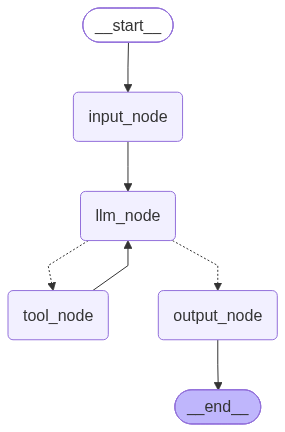

In [19]:
from langgraph.constants import END


# 1、声明状态
class OverAllState(MessagesState):
    user_input: str
    final_output: str


# 2、声明节点
# 2.1 输入节点->将用户输入的查询信息，记录到messages中，方便后续的模型调用
def input_node(state: OverAllState) -> OverAllState:
    return {
        "messages": [HumanMessage(state["user_input"])]
    }


# 2.2 大模型节点
def llm_node(state: OverAllState) -> OverAllState:
    ai_msg = model_with_tool.invoke(state["messages"])
    return {
        "messages": ai_msg
    }


# 2.3 判断是否需要调用工具
def tool_node(state: OverAllState) -> OverAllState:
    # 判断到模型的返回信息，是否需要调用tool
    messages = state["messages"]
    # [-1]表示最后一条消息
    ai_msg = messages[-1]
    tool_calls = ai_msg.tool_calls

    # 6表示函数调用60%失败
    fail_prob = 6

    for tool_call in tool_calls:
        if tool_call["name"] == "get_weather":
            # 生成[0-9]数字 判断大小
            if randint(0, 9) < fail_prob:
                messages.append(ToolMessage(
                    content="网络波动，调用失败，请重试",
                    tool_call_id=tool_call["id"]
                ))
            else:
                messages.append(get_weather.invoke(tool_call))
        elif tool_call["name"] == "get_news":
            if randint(0, 9) < fail_prob:
                messages.append(ToolMessage(
                    content="网络波动，调用失败，请重试",
                    tool_call_id=tool_call["id"]
                ))
            else:
                messages.append(get_news.invoke(tool_call))
        else:
            messages.append(ToolMessage(
                content="工具名称错误，调用失败，请重试",
                tool_call_id=tool_call["id"]
            ))
    return {
        "messages": messages
    }


# 2.4 返回输出节点
def output_node(state: OverAllState) -> OverAllState:
    # print(f"all_messages : ", state["messages"])
    return {
        "final_output": state["messages"][-1].content
    }


# 2.5 判断是否需要进行工具节点的调用，还是直接输出到output节点
def router(state: OverAllState) -> Literal["tool_node", "output_node"]:
    messages = state["messages"]
    last_msg = messages[-1]
    if last_msg.tool_calls:
        return "tool_node"
    return "output_node"


# 3、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("input_node", input_node)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_node("output_node", output_node)

builder.add_edge(START, "input_node")
builder.add_edge("input_node", "llm_node")
builder.add_conditional_edges("llm_node", router)
builder.add_edge("tool_node", "llm_node")
builder.add_edge("output_node", END)

graph = builder.compile()
ai_res = graph.invoke({
    "user_input": "查询今天的上海天气和AI新闻热点",
    "messages": [SystemMessage("如果工具调用失败，必须重新调用直到成功为止")]
})

print("user_input:", ai_res["user_input"])
print("final_output:", ai_res["final_output"])
for msg in ai_res["messages"]:
    msg.pretty_print()

display(graph)